##  Data
**Source:** IBM Telco Customer Churn Dataset — Kaggle (`blastchar/telco-customer-churn`)  
**Unit of observation:** One individual telecom customer.  
**Size:** 7,043 rows × 21 columns (before cleaning)

### a. Load Data

In [30]:
import kagglehub
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
from sklearn.preprocessing import LabelEncoder

# Download Telco dataset
path = kagglehub.dataset_download("blastchar/telco-customer-churn")
Telco = pd.read_csv(os.path.join(path, "WA_Fn-UseC_-Telco-Customer-Churn.csv"))

print("Shape:", Telco.shape)
Telco.head()

Shape: (7043, 21)


,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### b. First Look : Types, Missing Values, Churn Rate

In [35]:
# ──  First look at the data ──────────────────────────────

# 1. Column types and missing values
print("=== Column Info ==================")
print(Telco.dtypes)

# 2. Check churn rate
print("\n=== Churn Rate ===============")
print(Telco['Churn'].value_counts())
print(Telco['Churn'].value_counts(normalize=True).round(3) * 100, "%")

# 3. Check for missing values
print("\n=== Missing Values ==============")
print(Telco.isnull().sum())

# 4. Fix 'TotalCharges' (stored as str)
Telco['TotalCharges'] = pd.to_numeric(Telco['TotalCharges'], errors='coerce')
print("\n=== TotalCharges missing after fix ===")
print(Telco['TotalCharges'].isnull().sum())

=== Column Info ==================
gender                  str
SeniorCitizen         int64
Partner                 str
Dependents              str
tenure                int64
PhoneService            str
MultipleLines           str
InternetService         str
OnlineSecurity          str
OnlineBackup            str
DeviceProtection        str
TechSupport             str
StreamingTV             str
StreamingMovies         str
Contract                str
PaperlessBilling        str
PaymentMethod           str
MonthlyCharges      float64
TotalCharges        float64
Churn                 int64
dtype: object

=== Churn Rate ===============
Churn
0    5163
1    1869
Name: count, dtype: int64
Churn
0    73.4
1    26.6
Name: proportion, dtype: float64 %

=== Missing Values ==============
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup 

### c. Clean the data

In [32]:
# ──  Clean the data ───────────────────────────────────────

# 1. Fix Churn -> 0/1
Telco['Churn'] = Telco['Churn'].map({'Yes': 1, 'No': 0})

# 2. Drop the 11 rows with missing 'TotalCharges'
Telco = Telco.dropna(subset=['TotalCharges'])

# 3. Drop customerID - useless column (id)
Telco = Telco.drop(columns=['customerID'])

# 4. Fix "No internet service" -> "No" 
cols_with_no_internet = [
    'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
    'TechSupport', 'StreamingTV', 'StreamingMovies'
]
Telco[cols_with_no_internet] = Telco[cols_with_no_internet].replace(
    'No internet service', 'No'
)

# 5. Fix "No phone service" -> "No"
Telco['MultipleLines'] = Telco['MultipleLines'].replace('No phone service', 'No')

# Check
print("=== Shape after cleaning =============")
print(Telco.shape)

print("\n=== Churn distribution ===============")
print(Telco['Churn'].value_counts())

print("\n=== Sample ===============")
Telco.head(3)

=== Shape after cleaning =============
(7032, 20)

=== Churn distribution ===============
Churn
0    5163
1    1869
Name: count, dtype: int64

=== Sample ===============


,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1


### d. Target Variable - How Many Customers Churned?


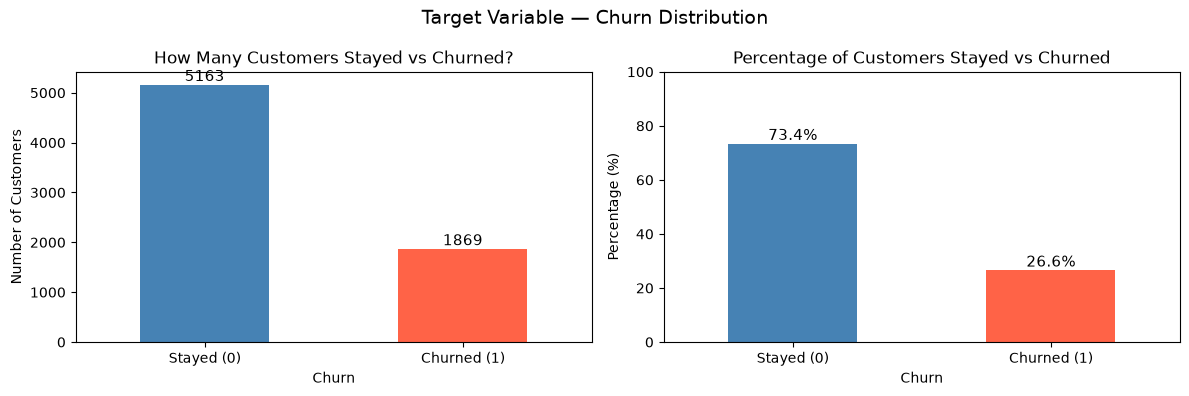

In [45]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Count
Telco['Churn'].value_counts().plot(kind='bar', ax=axes[0],
                                    color=['steelblue', 'tomato'])
axes[0].set_title('How Many Customers Stayed vs Churned?')
axes[0].set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)
axes[0].set_ylabel('Number of Customers')
for p in axes[0].patches:
    axes[0].annotate(f'{int(p.get_height())}',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

# Percentage
Telco['Churn'].value_counts(normalize=True).mul(100).plot(
    kind='bar', ax=axes[1], color=['steelblue', 'tomato'])
axes[1].set_title('Percentage of Customers Stayed vs Churned')
axes[1].set_xticklabels(['Stayed (0)', 'Churned (1)'], rotation=0)
axes[1].set_ylabel('Percentage (%)')
axes[1].set_ylim(0, 100)
for p in axes[1].patches:
    axes[1].annotate(f'{p.get_height():.1f}%',
                     (p.get_x() + p.get_width()/2, p.get_height()),
                     ha='center', va='bottom', fontsize=11)

plt.suptitle('Target Variable — Churn Distribution', fontsize=14)
plt.tight_layout()
plt.savefig('../data/churn_distribution.png', bbox_inches='tight')
plt.show()

### e. Feature Importance ; which features are most strongly related to churn? 

We rank all features by their correlation with Churn. This tells us which features to focus on in our EDA and confirms our choice of treatment and confounder variables.

C:\Users\Leila\AppData\Local\Temp\ipykernel_5516\2647237374.py:9: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  for col in Telco_encoded.select_dtypes(include='object').columns:


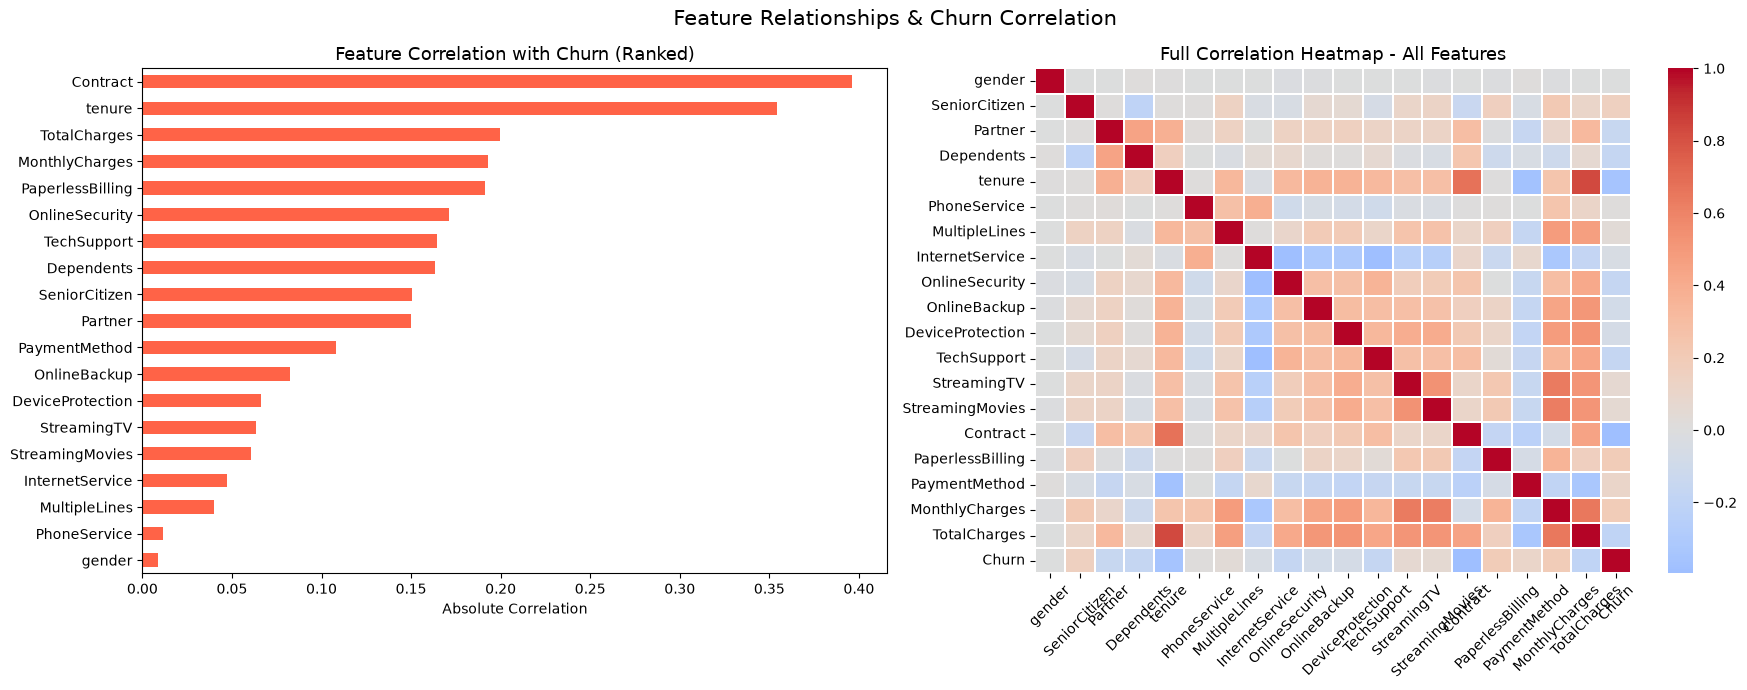

=== Top 4 Features Correlated with Churn =============
Contract            0.396
tenure              0.354
TotalCharges        0.199
MonthlyCharges      0.193
PaperlessBilling    0.191
Name: Churn, dtype: float64


In [46]:
# ──  Feature Correlation Heatmap ─────────────────────────────
from sklearn.preprocessing import LabelEncoder
import matplotlib.pyplot as plt
import seaborn as sns


# Encode all categorical columns temporarily
Telco_encoded = Telco.copy()
for col in Telco_encoded.select_dtypes(include='object').columns:
    Telco_encoded[col] = LabelEncoder().fit_transform(Telco_encoded[col])

# Correlation with Churn — ranked bar plot
churn_corr = Telco_encoded.corr()['Churn'].drop('Churn').abs().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Plot 1 — Ranked bar chart
churn_corr.plot(kind='barh', ax=axes[0], color='tomato')
axes[0].set_title('Feature Correlation with Churn (Ranked)', fontsize=13)
axes[0].set_xlabel('Absolute Correlation')
axes[0].invert_yaxis()

# Plot 2 — Full heatmap of all features
full_corr = Telco_encoded.corr()
sns.heatmap(full_corr, 
            annot=False,          # too many features for numbers
            cmap='coolwarm',
            center=0,
            linewidths=0.3,
            ax=axes[1])
axes[1].set_title('Full Correlation Heatmap - All Features', fontsize=13)
axes[1].tick_params(axis='x', rotation=45)
axes[1].tick_params(axis='y', rotation=0)

plt.suptitle('Feature Relationships & Churn Correlation', fontsize=15)
plt.tight_layout()
plt.savefig('../data/full_correlation.png', bbox_inches='tight')
plt.show()

print("=== Top 4 Features Correlated with Churn =============")
print(churn_corr.head(5).round(3))

### f. Categorical Features - Stayed vs Churned

Now we look at each categorical column and ask: **does this feature affect whether a customer churns?**

We plot Stayed (blue) and Churned (red) side by side for each category so the difference is immediately visible.

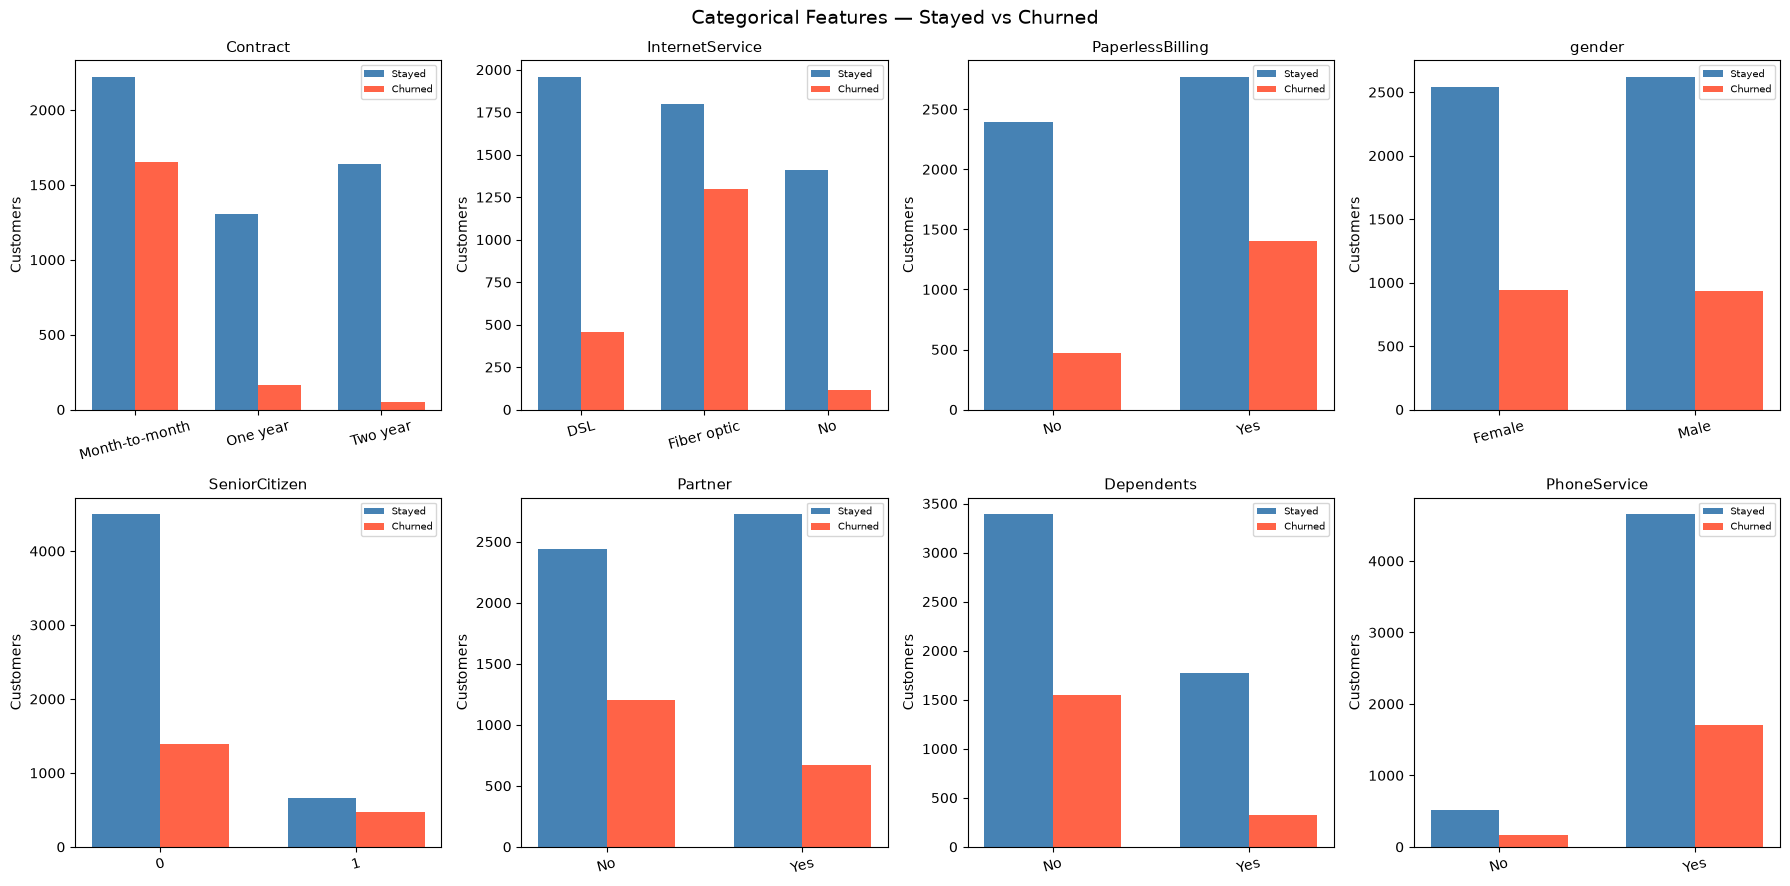

In [48]:
# All categorical features including Contract
cat_cols = ['Contract', 'InternetService', 'PaperlessBilling',
            'gender', 'SeniorCitizen', 'Partner',
            'Dependents', 'PhoneService']

fig, axes = plt.subplots(2, 4, figsize=(18, 9))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    stayed  = Telco[Telco['Churn']==0].groupby(col).size()
    churned = Telco[Telco['Churn']==1].groupby(col).size()
    x = range(len(stayed))
    width = 0.35
    axes[i].bar([p - width/2 for p in x], stayed.values,  width,
                label='Stayed',  color='steelblue')
    axes[i].bar([p + width/2 for p in x], churned.values, width,
                label='Churned', color='tomato')
    axes[i].set_title(col, fontsize=11)
    axes[i].set_xticks(list(x))
    axes[i].set_xticklabels(stayed.index, rotation=15)
    axes[i].set_ylabel('Customers')
    axes[i].legend(fontsize=7)

plt.suptitle('Categorical Features — Stayed vs Churned', fontsize=14)
plt.tight_layout()
plt.savefig('../data/categorical_churn.png', bbox_inches='tight')
plt.show()

### g. Continuous Features - Distribution by Churn Status

For numeric columns (tenure, MonthlyCharges, TotalCharges) we look at the **shape of the distribution** for stayed vs churned customers separately.

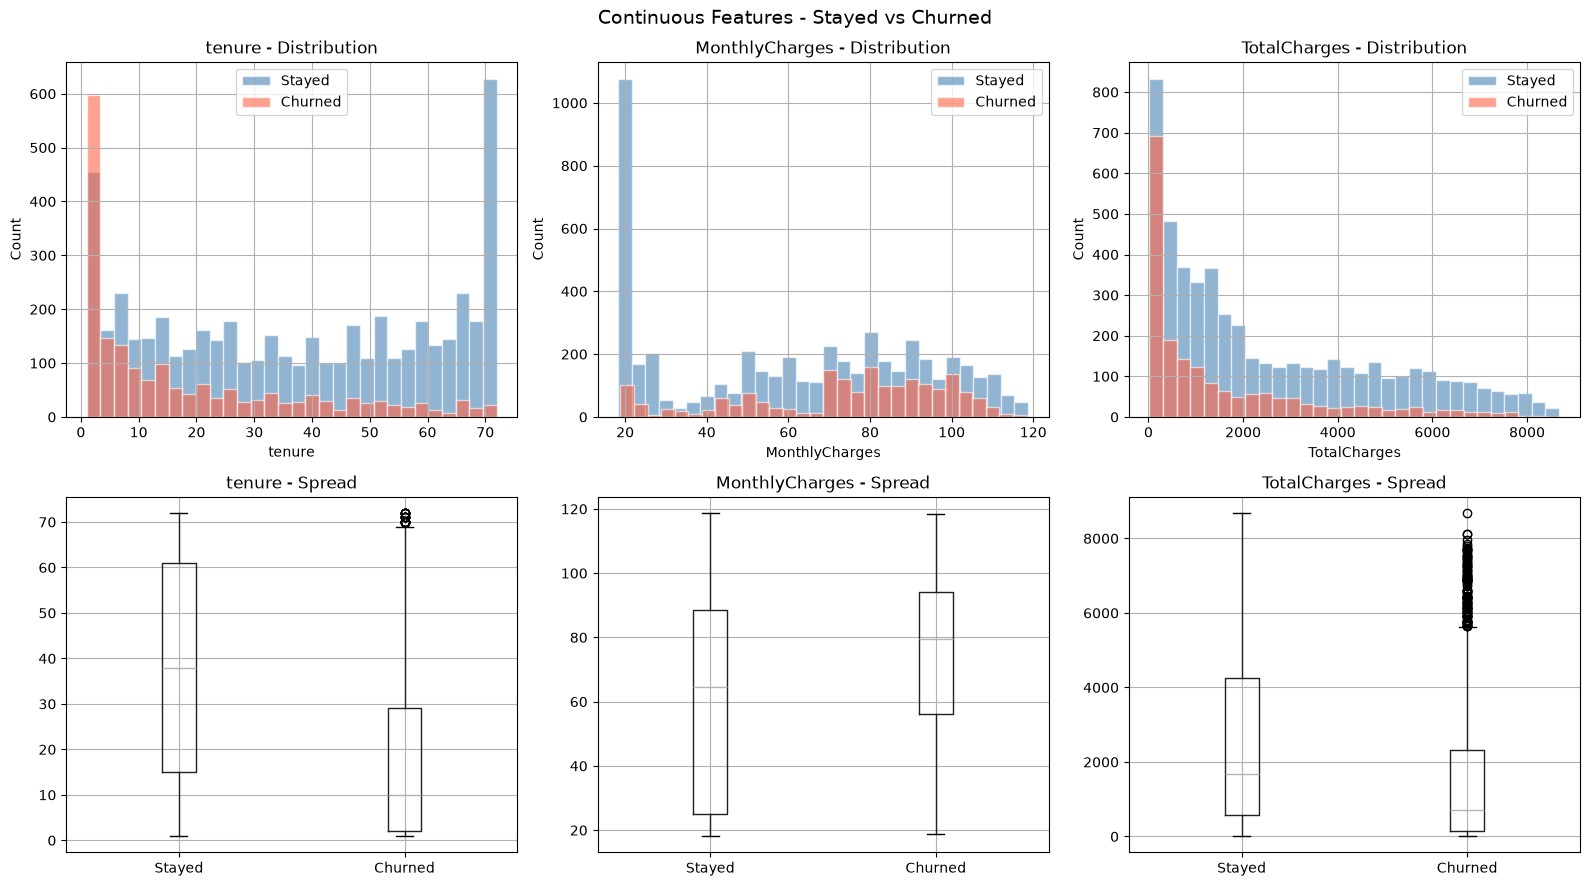

In [52]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))

cont_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']

# Row 1 — Histograms (shape of distribution)
for ax, col in zip(axes[0], cont_cols):
    Telco[Telco['Churn']==0][col].hist(ax=ax, bins=30, alpha=0.6,
        color='steelblue', label='Stayed', edgecolor='white')
    Telco[Telco['Churn']==1][col].hist(ax=ax, bins=30, alpha=0.6,
        color='tomato',    label='Churned', edgecolor='white')
    ax.set_title(f'{col} - Distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.legend()

# Row 2 — Boxplots (median + spread + outliers)
for ax, col in zip(axes[1], cont_cols):
    Telco.boxplot(column=col, by='Churn', ax=ax)
    ax.set_title(f'{col} - Spread')
    ax.set_xlabel('')
    ax.set_xticklabels(['Stayed', 'Churned'])
    plt.sca(ax)
    plt.title(f'{col} - Spread')

plt.suptitle('Continuous Features - Stayed vs Churned', fontsize=14)
plt.tight_layout()
plt.savefig('../data/continuous_distributions.png', bbox_inches='tight')
plt.show()

### h. EDA Summary & Key Findings

**1. Class Imbalance:** 73.4% stayed vs 26.6% churned.

**2. Contract type is the strongest signal:** Month-to-month customers churn at ~42%, compared to ~5% for two-year contracts. 

**3. Tenure effect:** Churned customers are concentrated at low tenure (new customers). 

**4. Monthly Charges:** Churned customers pay higher monthly charges on average.

**5. Multicollinearity warning:** TotalCharges and tenure are highly correlated (r≈0.83) - TotalCharges is mathematically a function of tenure × MonthlyCharges. 

**6. Senior citizens** show a noticeably higher churn rate than non-seniors.